### Agentic RAG with LangGraph

In [1]:

import os
from typing import TypedDict, List
from langgraph.graph import StateGraph, END
# from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_groq import ChatGroq
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_openai import ChatOpenAI
from langchain_community.embeddings import HuggingFaceEmbeddings

c:\Users\Yash\OneDrive\Desktop\RAG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
import os

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

# initialize models
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0
)

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

C:\Users\Yash\AppData\Local\Temp\ipykernel_6752\1392845232.py:11: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 891.75it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001F94023D5D0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001F93AA7E110>, model_name='llama-3.1-8b-instant', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'))

### State definition

In [5]:
# ---------------- STATE ----------------
class AgentState(TypedDict):
    question: str
    retrieved_docs: List[Document]
    answer: str
    decision: str
    satisfied: bool


In [6]:
### Sample Docuemnt And VectorStore
# Sample documents for demonstration
sample_texts = [
    "LangGraph is a library for building stateful, multi-actor applications with LLMs. It extends LangChain with the ability to coordinate multiple chains across multiple steps of computation in a cyclic manner.",
    "RAG (Retrieval-Augmented Generation) is a technique that combines information retrieval with text generation. It retrieves relevant documents and uses them to provide context for generating more accurate responses.",
    "Vector databases store high-dimensional vectors and enable efficient similarity search. They are commonly used in RAG systems to find relevant documents based on semantic similarity.",
    "Agentic systems are AI systems that can take actions, make decisions, and interact with their environment autonomously. They often use planning and reasoning capabilities."
]

documents=[Document(page_content=text) for text in sample_texts]

##create vector store
vectorstore = FAISS.from_documents(documents, embeddings)
retriever = vectorstore.as_retriever(k=3)

### Agents Function

In [7]:
# 1. LLM decides (AGENT BRAIN 🔥)
def decide(state: AgentState):
    question = state["question"]

    decision = llm.invoke(f"""
Question: {question}

Should I retrieve documents or answer directly?
Reply ONLY with: retrieve or answer
""").content.strip().lower()

    return {**state, "decision": decision}

In [8]:
# 2. Retrieve
def retrieve(state: AgentState):
    docs = retriever.invoke(state["question"])
    return {**state, "retrieved_docs": docs}

In [9]:
# 3. Generate
def generate(state: AgentState):
    question = state["question"]
    docs = state.get("retrieved_docs", [])

    if docs:
        context = "\n".join([doc.page_content for doc in docs])
        prompt = f"""
Context:
{context}

Question: {question}
Answer:
"""
    else:
        prompt = f"Question: {question}\nAnswer:"

    answer = llm.invoke(prompt).content
    return {**state, "answer": answer}

In [10]:
# 4. Evaluate (AGENT THINKING 🔥)
def evaluate(state: AgentState):
    question = state["question"]
    answer = state["answer"]

    result = llm.invoke(f"""
Question: {question}
Answer: {answer}

Is this answer sufficient and correct?
Reply ONLY with YES or NO.
""").content.lower()

    satisfied = "yes" in result
    return {**state, "satisfied": satisfied}

In [11]:
# 5. Refine query (if not satisfied)
def refine(state: AgentState):
    question = state["question"]

    new_question = llm.invoke(f"""
Improve this query for better retrieval:
{question}
""").content

    return {**state, "question": new_question}

### Routing

In [12]:
def route_decision(state: AgentState):
    return state["decision"]

def route_eval(state: AgentState):
    return "end" if state["satisfied"] else "refine"

### build the graph

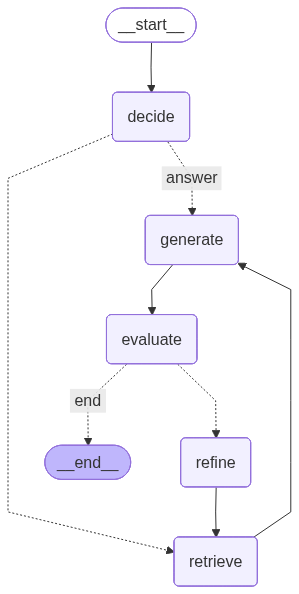

In [13]:
# ---------------- GRAPH ----------------

workflow = StateGraph(AgentState)

workflow.add_node("decide", decide)
workflow.add_node("retrieve", retrieve)
workflow.add_node("generate", generate)
workflow.add_node("evaluate", evaluate)
workflow.add_node("refine", refine)

workflow.set_entry_point("decide")

# Decision routing
workflow.add_conditional_edges(
    "decide",
    route_decision,
    {
        "retrieve": "retrieve",
        "answer": "generate"
    }
)

workflow.add_edge("retrieve", "generate")
workflow.add_edge("generate", "evaluate")

# LOOP 🔥 (this makes it agentic)
workflow.add_conditional_edges(
    "evaluate",
    route_eval,
    {
        "refine": "refine",
        "end": END
    }
)

workflow.add_edge("refine", "retrieve")

app = workflow.compile()
app

### test the Agentic System

In [14]:
def ask_question(question: str):
    state = {
        "question": question,
        "retrieved_docs": [],
        "answer": "",
        "decision": "",
        "satisfied": False
    }
    
    result = app.invoke(state)
    return result

In [15]:

# Test with a question that should trigger retrieval
question1 = "What is LangGraph?"
result1 = ask_question(question1)
result1

{'question': 'What is LangGraph?',
 'retrieved_docs': [Document(id='8e50a656-2a4b-4745-b2eb-7e888628cef8', metadata={}, page_content='LangGraph is a library for building stateful, multi-actor applications with LLMs. It extends LangChain with the ability to coordinate multiple chains across multiple steps of computation in a cyclic manner.'),
  Document(id='e594188f-b4dc-4242-9516-809f5c48e864', metadata={}, page_content='RAG (Retrieval-Augmented Generation) is a technique that combines information retrieval with text generation. It retrieves relevant documents and uses them to provide context for generating more accurate responses.'),
  Document(id='24965c48-5a7e-4b31-b4c9-e065442e88d8', metadata={}, page_content='Vector databases store high-dimensional vectors and enable efficient similarity search. They are commonly used in RAG systems to find relevant documents based on semantic similarity.'),
  Document(id='ee5b69bb-27d3-4c69-adce-35bdc0eb4f56', metadata={}, page_content='Agentic s

In [16]:
#Test with another question
question2 = "How does RAG work?"
result2 = ask_question(question2)

print(f"Question: {question2}")
print(f"Retrieved documents: {len(result2['retrieved_docs'])}")
print(f"Answer: {result2['answer']}")
print("\n" + "="*50 + "\n") 

Question: How does RAG work?
Retrieved documents: 4
Answer: RAG (Retrieval-Augmented Generation) is a technique that combines information retrieval with text generation to produce more accurate and informative responses. Here's a step-by-step explanation of how RAG works:

1. **Text Input**: The user provides a text input or query to the RAG system.
2. **Document Retrieval**: The RAG system uses a vector database to retrieve relevant documents from a large corpus of text. This is done by converting the input query into a high-dimensional vector and searching for similar vectors in the database. The retrieved documents are often ranked based on their semantic similarity to the input query.
3. **Document Ranking**: The retrieved documents are ranked based on their relevance to the input query. This ranking can be done using various techniques such as TF-IDF (Term Frequency-Inverse Document Frequency), BM25, or deep learning-based models.
4. **Document Selection**: The top-ranked document